In [155]:
# General import
import os

# 3rd-party import
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Local import

In [156]:
def get_limits(color):
	c = np.uint8([[color]]) # BGR values to convert to HSV
	hsvC = cv2.cvtColor(c, cv2.COLOR_BGR2HSV)
	
	lowerLimit = hsvC[0][0][0] - 6, 150, 50
	upperLimit = hsvC[0][0][0] + 6, 255, 255
	
	lowerLimit = np.array(lowerLimit, dtype=np.uint8)
	upperLimit = np.array(upperLimit, dtype=np.uint8)
	
	return lowerLimit, upperLimit

In [157]:
yellow = [0, 255, 255] # yellow in BGR colorspace
lowerLimit, upperLimit = get_limits(color=yellow)

In [158]:
img_path = '../data/lemon.jpg'
img = cv2.imread(img_path)

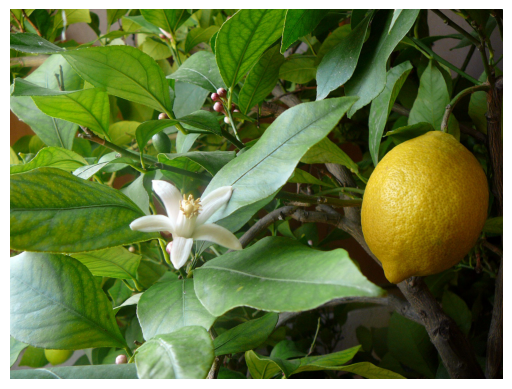

In [159]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

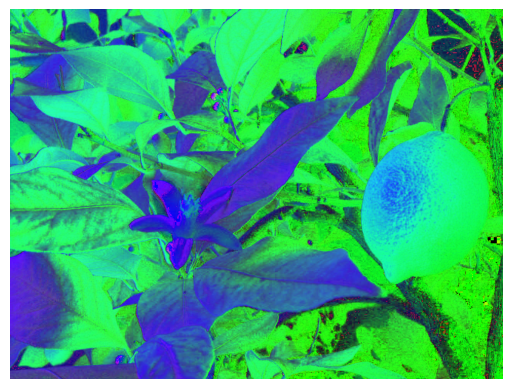

In [160]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
plt.imshow(img_hsv)
plt.axis('off')
plt.show()

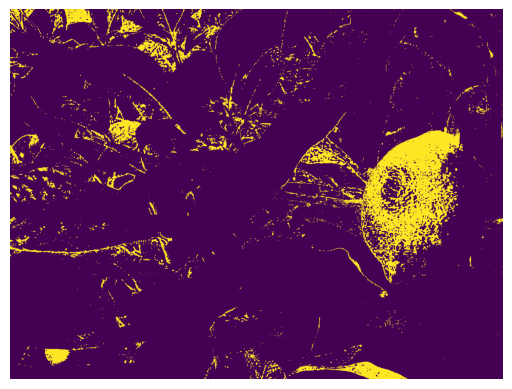

In [161]:
yellow_mask = cv2.inRange(img_hsv, lowerLimit, upperLimit)
plt.imshow(yellow_mask)
plt.axis('off')
plt.show()

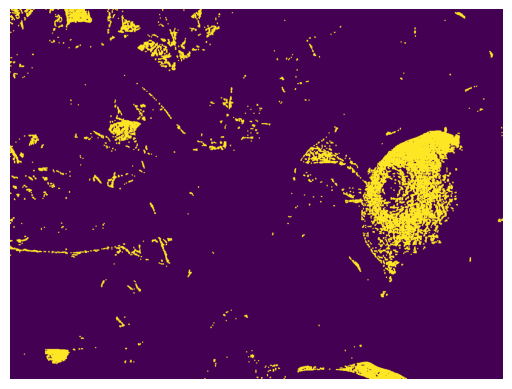

In [162]:
kernel = np.ones((3, 3), np.uint8)  
yellow_mask = cv2.erode(yellow_mask, kernel, iterations=1)  
yellow_mask = cv2.dilate(yellow_mask, kernel, iterations=1)  

plt.imshow(yellow_mask)
plt.axis('off')
plt.show()

In [163]:
# mask = Image.fromarray(mask)
# bbox = mask.getbbox()

# if bbox is not None:
#     x1, y1, x2, y2 = bbox

#     bbox_area = (x2 - x1) * (y2 - y1)
#     min_area_threshold = 1000  
    
#     if bbox_area > min_area_threshold:
#         cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 5)

In [164]:
yellow_contours, _ = cv2.findContours(yellow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 4000

for contour in yellow_contours:
    area = cv2.contourArea(contour)
    if area > min_area:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 5)

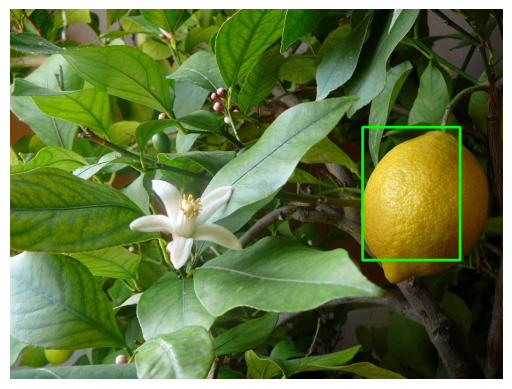

In [165]:
plt.imshow(img_rgb)
plt.axis('off')
plt.show()